# Laboratorio 07 - Punto 1: KMeans con datos generados en 2D

Estudiante: Arduz Espada Juan Sebastian

Materia: SIS 420 - Inteligencia Artificial I

Lo que pide el punto:
- Modificar el generador de dataset aleatorio para que genere entre 1 y 20 centroides, bien separados entre ellos para poder verificar a simple vista si el modelo acerto.
- Posiciones de los centroides al azar.
- Distancia de los puntos a su centroide al azar.
- Cantidad de puntos por centroide al azar.
- Aplicar KMeans y mostrar donde quedaron los centroides, cuantos puntos tiene cada uno y los 5 puntos mas cercanos a cada centroide.
- Graficar todo el proceso.

Todo el trabajo es con puntos de **2 dimensiones**. El mismo codigo del punto 1 sirve para el punto 2 cambiando solo la variable DIMENSION, porque las cuentas de KMeans (distancia, promedio) son iguales sin importar cuantas dimensiones haya.

## 1. Librerias y configuracion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

DIMENSION = 2
SEMILLA = 42
DISTANCIA_MINIMA = 20.0
rng = np.random.RandomState(SEMILLA)

print('Dimension de los puntos:', DIMENSION)
print('Distancia minima entre centroides:', DISTANCIA_MINIMA)

Dimension de los puntos: 2
Distancia minima entre centroides: 20.0


## 2. Generador de dataset aleatorio

El generador del cuadernillo creaba los puntos alrededor de centroides fijos. Lo modifique para que todo sea al azar y para que los grupos queden separados:

- **Cantidad de centroides:** un numero al azar entre 1 y 20.
- **Posicion de los centroides:** al azar, pero obligando a que entre dos centroides cualesquiera haya al menos 20 de distancia. Para eso voy sorteando posiciones y descarto las que caen muy cerca de una ya aceptada (eso se llama muestreo por rechazo).
- **Distancia de los puntos a su centroide:** cada centroide recibe su propia dispersion al azar, o sea que unos grupos salen mas apretados y otros mas abiertos.
- **Cantidad de puntos por centroide:** tambien al azar, entre 60 y 400, asi que los grupos no tienen el mismo tamanio.

La dispersion la limito a la sexta parte de la distancia minima. Como casi todos los puntos de una normal caen dentro de 3 desviaciones, un grupo ocupa como mucho la mitad de la distancia que hay hasta el grupo vecino, y por eso los grupos se ven separados en la grafica.

In [2]:
def generar_centroides(k, dimension, rng, distancia_minima=DISTANCIA_MINIMA):
    """Sortea k posiciones al azar que esten separadas al menos distancia_minima."""
    # el lado del area crece con la cantidad de centroides para que siempre haya lugar
    lado = distancia_minima * (k ** (1.0 / dimension)) * 2.2
    centros = []
    intentos = 0
    while len(centros) < k and intentos < 20000:
        intentos += 1
        candidato = rng.uniform(0, lado, size=dimension)
        if all(np.linalg.norm(candidato - c) >= distancia_minima for c in centros):
            centros.append(candidato)
    if len(centros) < k:
        raise RuntimeError('no se pudieron colocar los centroides, hay que agrandar el area')
    return np.array(centros), lado


def generar_dataset(rng, k=None, dimension=DIMENSION, distancia_minima=DISTANCIA_MINIMA,
                    puntos_minimo=60, puntos_maximo=400):
    """Genera el dataset completo: centroides al azar, dispersion al azar y cantidad de puntos al azar."""
    if k is None:
        k = rng.randint(1, 21)                       # entre 1 y 20 centroides

    centros, lado = generar_centroides(k, dimension, rng, distancia_minima)
    dispersiones = rng.uniform(distancia_minima / 12, distancia_minima / 6, size=k)
    cantidades = rng.randint(puntos_minimo, puntos_maximo + 1, size=k)

    X, y_real = [], []
    for c in range(k):
        # los puntos se reparten alrededor del centroide con una normal de su propia dispersion
        puntos = centros[c] + rng.normal(0, dispersiones[c], size=(cantidades[c], dimension))
        X.append(puntos)
        y_real.append(np.full(cantidades[c], c))

    X = np.vstack(X)
    y_real = np.concatenate(y_real)
    orden = rng.permutation(len(X))                  # se mezclan para que no queden ordenados por grupo
    return X[orden], y_real[orden], centros, dispersiones, cantidades, lado


X, y_real, centros_reales, dispersiones, cantidades, lado = generar_dataset(rng)
K_REAL = len(centros_reales)

print('Centroides generados (k):', K_REAL)
print('Puntos totales (m):', len(X), '  Dimensiones (n):', X.shape[1])
print('Area usada:', round(lado, 1), 'x', round(lado, 1))
distancias_entre_centros = [np.linalg.norm(centros_reales[i] - centros_reales[j])
                            for i in range(K_REAL) for j in range(i + 1, K_REAL)]
if distancias_entre_centros:
    print('Distancia minima real entre centroides:', round(min(distancias_entre_centros), 2))
pd.DataFrame({'centroide': range(K_REAL),
              'posicion real': [np.round(c, 2) for c in centros_reales],
              'dispersion': np.round(dispersiones, 2),
              'puntos generados': cantidades})

Centroides generados (k): 7
Puntos totales (m): 1719   Dimensiones (n): 2
Area usada: 116.4 x 116.4
Distancia minima real entre centroides: 24.86


,centroide,posicion real,dispersion,puntos generados
0,0,"[92.73, 21.35]",2.69,330
1,1,"[90.77, 69.48]",1.68,249
2,2,"[51.9, 11.64]",1.71,234
3,3,"[53.46, 38.85]",2.54,110
4,4,"[16.63, 75.77]",2.33,114
5,5,"[109.26, 0.09]",1.74,303
6,6,"[115.51, 71.88]",3.29,379


## 3. Grafica del dataset generado

Cada color es un grupo real y la X negra es el centroide que uso para generarlo. Esta grafica es la verificacion visual: se tienen que ver los grupos separados.

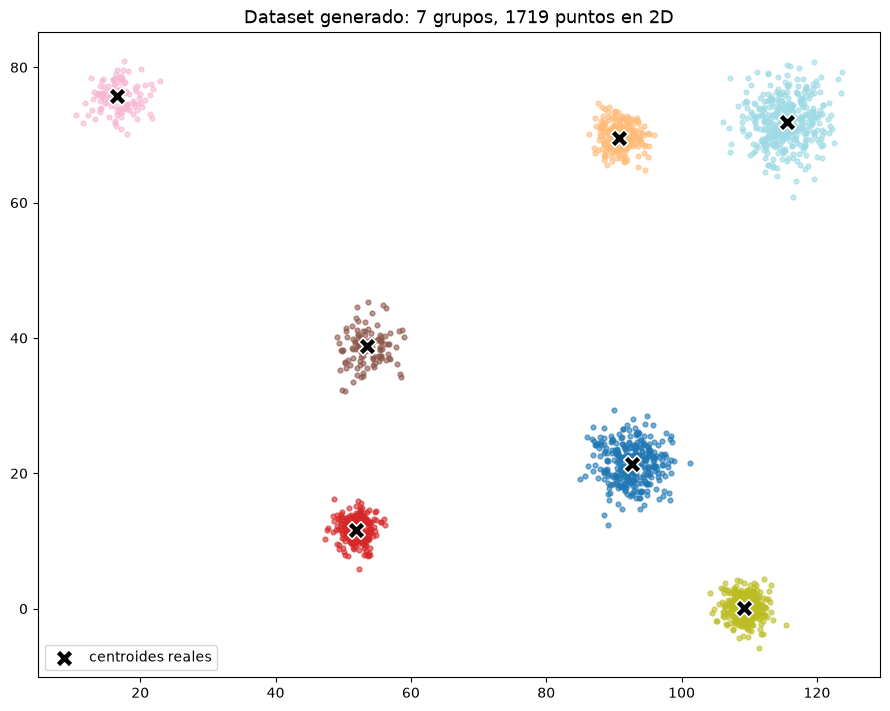

In [3]:
def nuevo_eje(fig, filas, columnas, posicion):
    """Devuelve un eje 2D o 3D segun la dimension con la que se esta trabajando."""
    if DIMENSION == 3:
        return fig.add_subplot(filas, columnas, posicion, projection='3d')
    eje = fig.add_subplot(filas, columnas, posicion)
    eje.set_aspect('equal')                      # misma escala en los dos ejes para que los grupos se vean redondos
    return eje


def dibujar_puntos(ax, X, etiquetas, k, tamanio=12, alpha=0.6):
    """Dibuja los puntos pintados segun el grupo al que pertenecen."""
    colores = plt.cm.tab20(np.linspace(0, 1, max(k, 2)))
    for c in range(k):
        grupo = X[etiquetas == c]
        if len(grupo) > 0:
            ax.scatter(*grupo.T, s=tamanio, alpha=alpha, color=colores[c])


def dibujar_centros(ax, centros, marcador='X', color='black', tamanio=160, etiqueta=None):
    """Dibuja los centroides como marcadores grandes."""
    ax.scatter(*centros.T, marker=marcador, s=tamanio, c=color, edgecolors='white',
               linewidths=1.2, label=etiqueta, zorder=5)


fig = plt.figure(figsize=(9, 8))
ax = nuevo_eje(fig, 1, 1, 1)
dibujar_puntos(ax, X, y_real, K_REAL)
dibujar_centros(ax, centros_reales, etiqueta='centroides reales')
ax.set_title(f'Dataset generado: {K_REAL} grupos, {len(X)} puntos en {DIMENSION}D', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 4. KMeans

Programe KMeans a mano para poder guardar lo que pasa en cada iteracion y graficar el proceso. Los pasos son los del cuadernillo:

1. Elegir los centroides iniciales.
2. **Asignacion:** cada punto va al centroide mas cercano (distancia euclidea).
3. **Actualizacion:** cada centroide se mueve al promedio de los puntos que le tocaron.
4. Repetir hasta que los centroides ya no se muevan.

Para los centroides iniciales uso kmeans++: el primero es un punto al azar y los siguientes se sortean dando mas probabilidad a los puntos que estan lejos de los centroides ya elegidos. Asi no empiezan todos juntos en la misma zona.

La **inercia** es la suma de las distancias al cuadrado de cada punto a su centroide. Es lo que KMeans va bajando en cada iteracion.

In [4]:
def distancias_a_centros(X, centros):
    """Matriz de distancias: una fila por punto y una columna por centroide."""
    return np.linalg.norm(X[:, None, :] - centros[None, :, :], axis=2)


def inicializar_kmeans_pp(X, k, rng):
    """kmeans++: el primer centro es al azar y los demas se sortean lejos de los ya elegidos."""
    centros = [X[rng.randint(len(X))]]
    for _ in range(k - 1):
        d2 = distancias_a_centros(X, np.array(centros)).min(axis=1) ** 2
        probabilidad = d2 / d2.sum() if d2.sum() > 0 else None
        centros.append(X[rng.choice(len(X), p=probabilidad)])
    return np.array(centros)


def inicializar_apretado(X, k, rng):
    """Arranque malo a proposito: todos los centros juntos cerca del promedio de los datos."""
    return X.mean(axis=0) + rng.normal(0, X.std(axis=0) * 0.05, size=(k, X.shape[1]))


def kmeans_manual(X, k, rng, max_iteraciones=100, tolerancia=1e-8, inicio='kmeans++'):
    """KMeans paso a paso. Devuelve tambien el historial para poder graficar el proceso."""
    centros = inicializar_kmeans_pp(X, k, rng) if inicio == 'kmeans++' else inicializar_apretado(X, k, rng)
    historial = []
    for iteracion in range(max_iteraciones):
        distancias = distancias_a_centros(X, centros)
        etiquetas = distancias.argmin(axis=1)                       # paso de asignacion
        inercia = (distancias[np.arange(len(X)), etiquetas] ** 2).sum()
        historial.append({'iteracion': iteracion, 'centros': centros.copy(),
                          'etiquetas': etiquetas.copy(), 'inercia': inercia})

        nuevos = np.array([X[etiquetas == c].mean(axis=0) if np.any(etiquetas == c) else centros[c]
                           for c in range(k)])                      # paso de actualizacion
        movimiento = np.linalg.norm(nuevos - centros)
        centros = nuevos
        if movimiento < tolerancia:                                 # ya no se mueven: termina
            break

    distancias = distancias_a_centros(X, centros)
    etiquetas = distancias.argmin(axis=1)
    inercia = (distancias[np.arange(len(X)), etiquetas] ** 2).sum()
    historial.append({'iteracion': len(historial), 'centros': centros.copy(),
                      'etiquetas': etiquetas.copy(), 'inercia': inercia})
    return centros, etiquetas, inercia, historial


centros_kmeans, etiquetas_kmeans, inercia_kmeans, historial = kmeans_manual(X, K_REAL, rng)
print('Iteraciones hasta converger:', len(historial) - 1)
print('Inercia final:', round(inercia_kmeans, 2))

Iteraciones hasta converger: 2
Inercia final: 20544.17


### Comparacion con el KMeans de scikit-learn

Para comprobar que mi implementacion esta bien, corro el KMeans de sklearn sobre los mismos datos y comparo la inercia y la posicion de los centroides.

In [5]:
modelo_sklearn = KMeans(n_clusters=K_REAL, n_init=10, random_state=SEMILLA).fit(X)

# cada centro mio se compara con el centro de sklearn que le quedo mas cerca
diferencia = distancias_a_centros(centros_kmeans, modelo_sklearn.cluster_centers_).min(axis=1)

print('Inercia mia:    ', round(inercia_kmeans, 4))
print('Inercia sklearn:', round(modelo_sklearn.inertia_, 4))
print('Diferencia maxima entre centroides de los dos metodos:', round(diferencia.max(), 6))

Inercia mia:     20544.1675
Inercia sklearn: 20544.1675
Diferencia maxima entre centroides de los dos metodos: 0.0


La inercia me da exactamente igual que a sklearn (20544.17) y los centroides quedan en el mismo lugar (la diferencia es 0.0). O sea que mi implementacion hace lo mismo que la de la libreria. Uso la mia porque me deja guardar cada iteracion y asi puedo graficar el proceso.

## 5. El proceso de KMeans, iteracion por iteracion

Con kmeans++ los centroides arrancan ya separados y el modelo termina en muy pocas iteraciones, asi que casi no se ve el proceso. Para que se note, repito el entrenamiento con un arranque malo a proposito: pongo todos los centroides juntos cerca del promedio de los datos y desde ahi se tienen que separar solos.

Cada cuadro es una iteracion: los puntos pintados segun a que centroide fueron asignados, y las X negras donde estaban los centroides en ese momento.

In [6]:
centros_demo, etiquetas_demo, inercia_demo, historial_demo = kmeans_manual(
    X, K_REAL, np.random.RandomState(SEMILLA), inicio='apretado')
print('Arranque apretado -> iteraciones:', len(historial_demo) - 1, ' inercia final:', round(inercia_demo, 2))
print('Arranque kmeans++ -> iteraciones:', len(historial) - 1, ' inercia final:', round(inercia_kmeans, 2))
print('Los dos arranques llegan a la misma solucion:', bool(np.isclose(inercia_demo, inercia_kmeans)))

Arranque apretado -> iteraciones: 10  inercia final: 73142.01
Arranque kmeans++ -> iteraciones: 2  inercia final: 20544.17
Los dos arranques llegan a la misma solucion: False


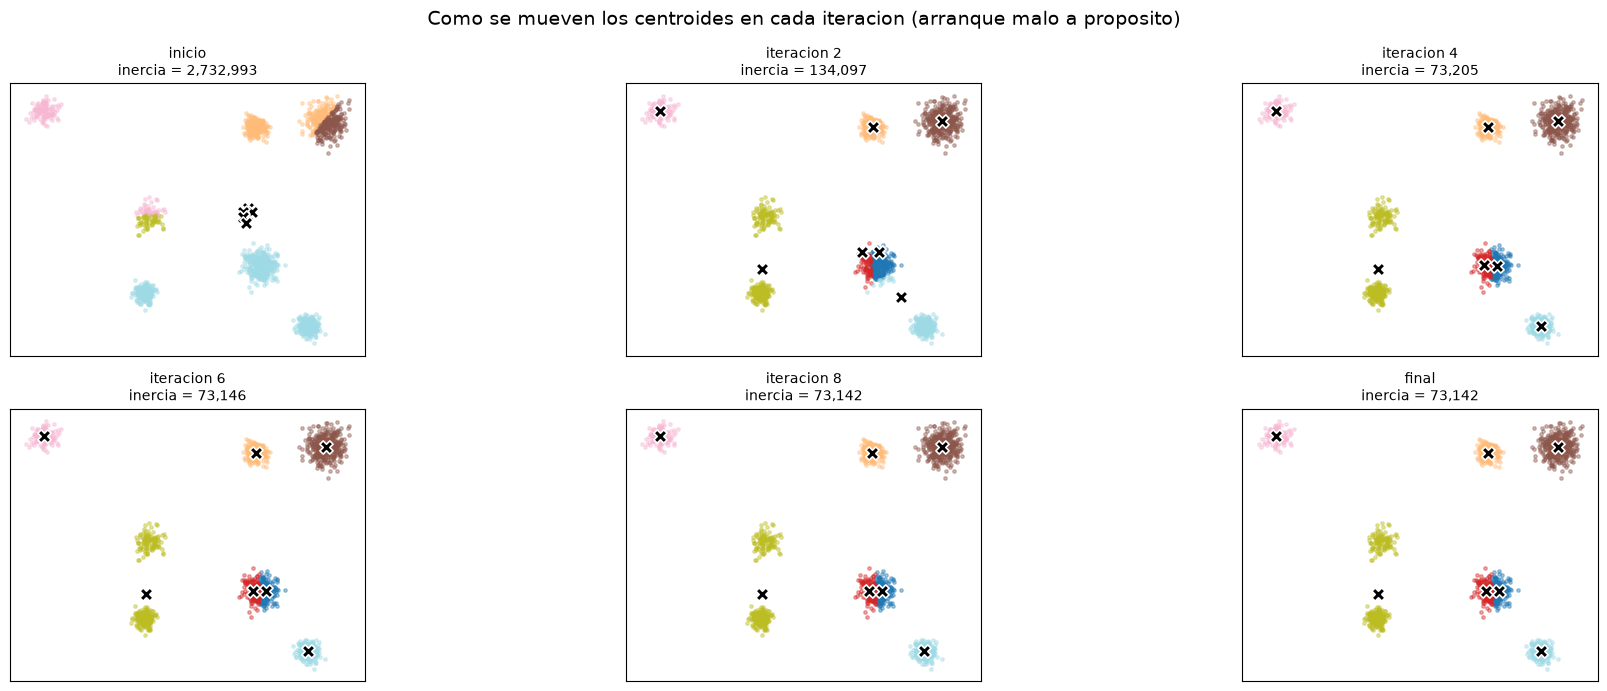

In [7]:
historial_grafica = historial_demo
cuadros = min(len(historial_grafica), 6)
indices_cuadros = np.linspace(0, len(historial_grafica) - 1, cuadros).astype(int)

fig = plt.figure(figsize=(20, 7))
for posicion, i in enumerate(indices_cuadros, start=1):
    paso = historial_grafica[i]
    ax = nuevo_eje(fig, 2, (cuadros + 1) // 2, posicion)
    dibujar_puntos(ax, X, paso['etiquetas'], K_REAL, tamanio=6, alpha=0.4)
    dibujar_centros(ax, paso['centros'], tamanio=90)
    titulo = 'inicio' if i == 0 else ('final' if i == len(historial_grafica) - 1 else f'iteracion {i}')
    ax.set_title(f'{titulo}\ninercia = {paso["inercia"]:,.0f}', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle('Como se mueven los centroides en cada iteracion (arranque malo a proposito)', fontsize=14)
plt.tight_layout()
plt.show()

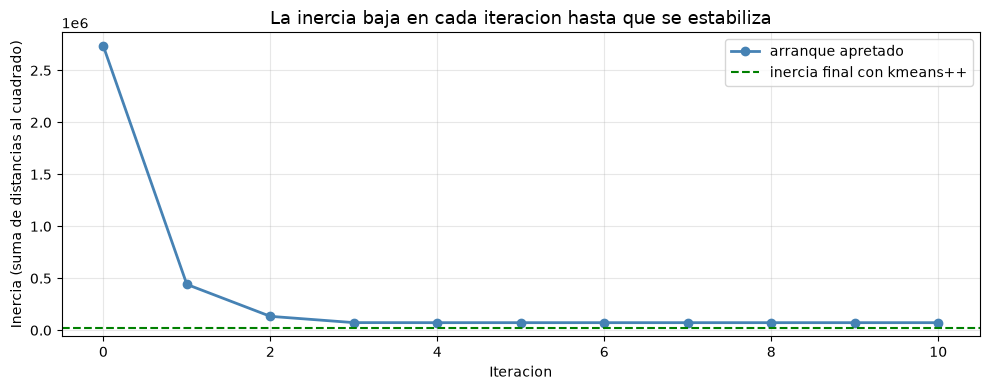

In [8]:
plt.figure(figsize=(10, 4))
plt.plot([p['iteracion'] for p in historial_grafica], [p['inercia'] for p in historial_grafica],
         marker='o', linewidth=2, color='steelblue', label='arranque apretado')
plt.axhline(inercia_kmeans, color='green', linestyle='--', label='inercia final con kmeans++')
plt.legend()
plt.title('La inercia baja en cada iteracion hasta que se estabiliza', fontsize=13)
plt.xlabel('Iteracion')
plt.ylabel('Inercia (suma de distancias al cuadrado)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Con el arranque malo el modelo tarda 10 iteraciones en acomodarse, contra 2 que tarda con kmeans++, y ademas termina peor: la inercia queda en 73142.01 contra 20544.17 de kmeans++.

En la grafica se ve por que: quedaron dos centroides dentro de un mismo grupo y otro grupo se quedo sin centroide. De ahi ya no puede salir, porque ningun punto cambia de grupo y entonces los centroides no se mueven mas.

Esto muestra que KMeans depende de donde arranca. Por eso conviene usar kmeans++ y correrlo varias veces (el n_init de sklearn) para quedarse con la corrida de menor inercia.

## 6. Resultado final

### 6.1 Donde quedaron los centroides

Comparo cada centroide que encontro KMeans con el centroide real mas cercano, que es el que use para generar los puntos.

In [9]:
distancia_a_reales = distancias_a_centros(centros_kmeans, centros_reales)
real_mas_cercano = distancia_a_reales.argmin(axis=1)
error_centro = distancia_a_reales.min(axis=1)
puntos_por_centro = np.bincount(etiquetas_kmeans, minlength=K_REAL)

resumen = pd.DataFrame({
    'centroide KMeans': range(K_REAL),
    'posicion encontrada': [np.round(c, 2) for c in centros_kmeans],
    'centroide real mas cercano': real_mas_cercano,
    'posicion real': [np.round(centros_reales[i], 2) for i in real_mas_cercano],
    'error (distancia)': np.round(error_centro, 3),
    'puntos asignados': puntos_por_centro,
    'puntos generados': cantidades[real_mas_cercano],
})
print('Error promedio entre el centroide encontrado y el real:', round(error_centro.mean(), 4))
print('Cada centroide encontrado cayo sobre un centroide real distinto:',
      len(set(real_mas_cercano)) == K_REAL)
resumen

Error promedio entre el centroide encontrado y el real: 0.1968
Cada centroide encontrado cayo sobre un centroide real distinto: True


,centroide KMeans,posicion encontrada,centroide real mas cercano,posicion real,error (distancia),puntos asignados,puntos generados
0,0,"[92.6, 21.45]",0,"[92.73, 21.35]",0.161,330,330
1,1,"[51.9, 11.73]",2,"[51.9, 11.64]",0.093,234,234
2,2,"[16.74, 75.59]",4,"[16.63, 75.77]",0.215,114,114
3,3,"[115.4, 71.98]",6,"[115.51, 71.88]",0.143,379,379
4,4,"[53.6, 38.61]",3,"[53.46, 38.85]",0.277,110,110
5,5,"[90.87, 69.81]",1,"[90.77, 69.48]",0.345,249,249
6,6,"[109.35, 0.2]",5,"[109.26, 0.09]",0.143,303,303


### 6.2 Cuantos puntos tiene cada centroide

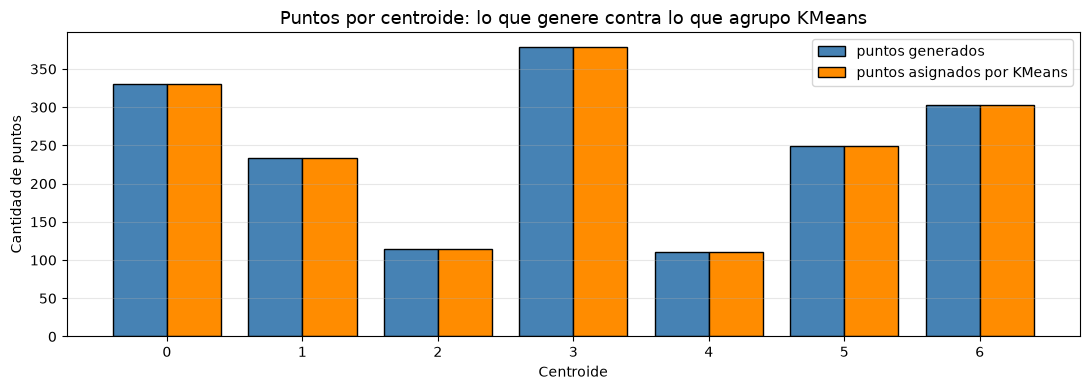

Puntos que KMeans puso en un grupo distinto al que se genero: 0 de 1719


In [10]:
plt.figure(figsize=(11, 4))
ancho = 0.4
posiciones = np.arange(K_REAL)
plt.bar(posiciones - ancho / 2, cantidades[real_mas_cercano], width=ancho,
        color='steelblue', edgecolor='black', label='puntos generados')
plt.bar(posiciones + ancho / 2, puntos_por_centro, width=ancho,
        color='darkorange', edgecolor='black', label='puntos asignados por KMeans')
plt.xticks(posiciones)
plt.xlabel('Centroide')
plt.ylabel('Cantidad de puntos')
plt.title('Puntos por centroide: lo que genere contra lo que agrupo KMeans', fontsize=13)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

mal_asignados = int((real_mas_cercano[etiquetas_kmeans] != y_real).sum())
print('Puntos que KMeans puso en un grupo distinto al que se genero:', mal_asignados, 'de', len(X))

### 6.3 Los 5 puntos mas cercanos a cada centroide

In [11]:
filas = []
cercanos_por_centro = {}
distancias_finales = distancias_a_centros(X, centros_kmeans)
for c in range(K_REAL):
    de_este_centro = np.where(etiquetas_kmeans == c)[0]
    orden = de_este_centro[np.argsort(distancias_finales[de_este_centro, c])][:5]
    cercanos_por_centro[c] = orden
    for puesto, indice in enumerate(orden, start=1):
        filas.append({'centroide': c, 'puesto': puesto, 'indice del punto': int(indice),
                      'coordenadas': np.round(X[indice], 2),
                      'distancia al centroide': round(distancias_finales[indice, c], 4)})
tabla_cercanos = pd.DataFrame(filas)
print('Los 5 puntos mas cercanos a cada uno de los', K_REAL, 'centroides:')
tabla_cercanos

Los 5 puntos mas cercanos a cada uno de los 7 centroides:


,centroide,puesto,indice del punto,coordenadas,distancia al centroide
0,0,1,121,"[92.63, 21.51]",0.0657
1,0,2,967,"[92.69, 21.28]",0.1909
2,0,3,311,"[92.88, 21.52]",0.2861
3,0,4,596,"[93.02, 21.64]",0.4612
4,0,5,1435,"[92.33, 21.84]",0.4711
5,1,1,1539,"[51.88, 11.83]",0.1031
6,1,2,312,"[52.02, 11.6]",0.1769
7,1,3,50,"[52.23, 11.47]",0.4152
8,1,4,1515,"[52.3, 11.61]",0.4170
9,1,5,612,"[52.2, 12.09]",0.4661


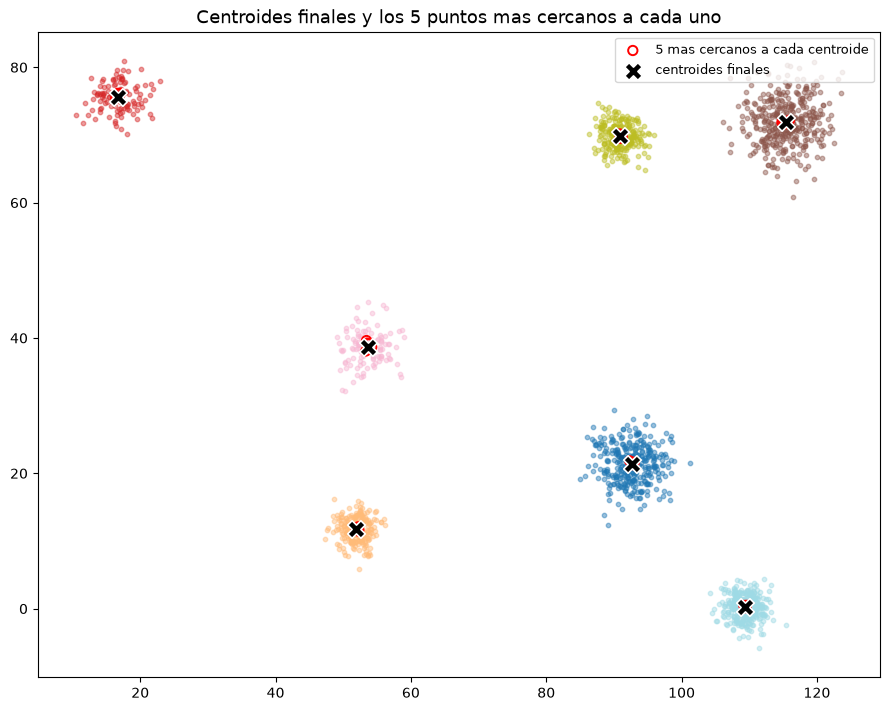

In [12]:
fig = plt.figure(figsize=(9, 8))
ax = nuevo_eje(fig, 1, 1, 1)
dibujar_puntos(ax, X, etiquetas_kmeans, K_REAL, tamanio=10, alpha=0.45)
indices_cercanos = np.concatenate([cercanos_por_centro[c] for c in range(K_REAL)])
ax.scatter(*X[indices_cercanos].T, s=45, facecolors='none', edgecolors='red',
           linewidths=1.4, label='5 mas cercanos a cada centroide')
dibujar_centros(ax, centros_kmeans, etiqueta='centroides finales')
ax.set_title('Centroides finales y los 5 puntos mas cercanos a cada uno', fontsize=13)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

Los centroides que encontro KMeans quedaron casi encima de los que use para generar los datos: el error promedio es de 0.20, y los centroides estan separados por mas de 20 entre si, asi que ese error es minimo.

Cada centroide encontrado cayo sobre un centroide real distinto (no se le escapo ninguno ni puso dos en el mismo grupo), la cantidad de puntos por grupo coincide con la que genere, y ningun punto quedo en el grupo equivocado (0 de 1719).

Los 5 puntos mas cercanos a cada centroide quedan pegados a el: sus distancias son mucho mas chicas que la dispersion del grupo, que es lo esperable porque son los puntos que cayeron justo en el centro de la nube.

## 7. Cuantos grupos hay: metodo del codo y silhouette

Hasta aca le dije a KMeans cuantos grupos buscar, pero en un problema real no se sabe. Las dos formas que vimos para decidirlo son:

- **Metodo del codo:** se grafica la inercia para varios k. La inercia siempre baja al agregar grupos, pero cuando se pasa del k correcto deja de bajar fuerte y la curva hace un codo.
- **Silhouette:** para cada punto mide que tan cerca esta de su grupo comparado con el grupo vecino mas cercano. Va de -1 a 1 y se elige el k con el promedio mas alto.

k real: 7   k detectado por silhouette: 7


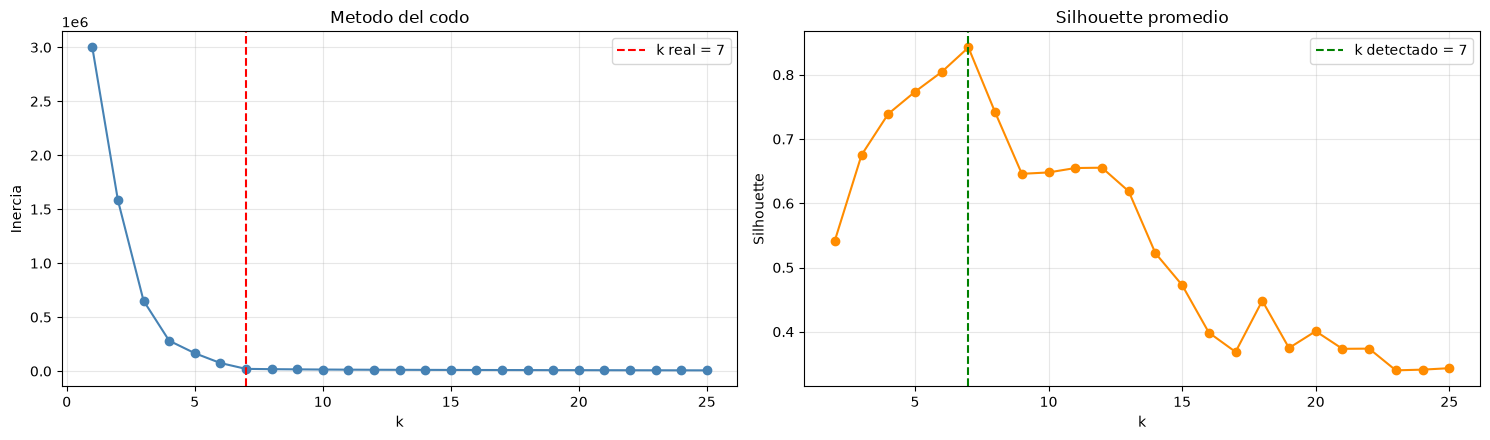

In [13]:
k_maximo = min(25, len(X) // 10)
ks = range(1, k_maximo + 1)
inercias, silhouettes = [], []
for k in ks:
    modelo = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(X)
    inercias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(X, modelo.labels_) if k > 1 else np.nan)

k_detectado = int(np.nanargmax(silhouettes) + 1)
print('k real:', K_REAL, '  k detectado por silhouette:', k_detectado)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))
ax1.plot(list(ks), inercias, marker='o', color='steelblue')
ax1.axvline(K_REAL, color='red', linestyle='--', label=f'k real = {K_REAL}')
ax1.set_title('Metodo del codo')
ax1.set_xlabel('k')
ax1.set_ylabel('Inercia')
ax2.plot(list(ks), silhouettes, marker='o', color='darkorange')
ax2.axvline(k_detectado, color='green', linestyle='--', label=f'k detectado = {k_detectado}')
ax2.set_title('Silhouette promedio')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette')
for ax in (ax1, ax2):
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Diagrama de silueta del k elegido

Cada franja es un grupo y cada linea dentro de la franja es un punto. Mientras mas larga la linea, mas seguro esta ese punto de pertenecer a su grupo.

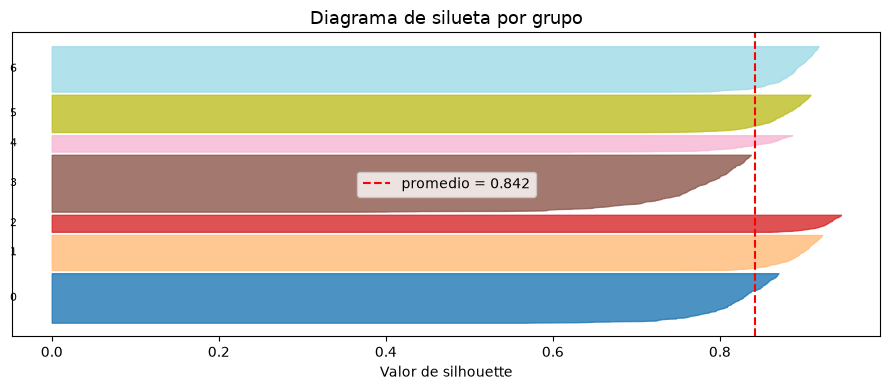

In [14]:
valores_silueta = silhouette_samples(X, etiquetas_kmeans) if K_REAL > 1 else np.zeros(len(X))
plt.figure(figsize=(9, max(4, K_REAL * 0.35)))
inicio = 0
colores = plt.cm.tab20(np.linspace(0, 1, max(K_REAL, 2)))
for c in range(K_REAL):
    valores = np.sort(valores_silueta[etiquetas_kmeans == c])
    plt.fill_betweenx(np.arange(inicio, inicio + len(valores)), 0, valores, color=colores[c], alpha=0.8)
    plt.text(-0.05, inicio + len(valores) / 2, str(c), fontsize=8, va='center')
    inicio += len(valores) + 20
plt.axvline(valores_silueta.mean(), color='red', linestyle='--',
            label=f'promedio = {valores_silueta.mean():.3f}')
plt.title('Diagrama de silueta por grupo', fontsize=13)
plt.xlabel('Valor de silhouette')
plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()

## 8. Validacion: funciona con cualquier cantidad de centroides?

Repito todo el proceso para varias cantidades de centroides dentro del rango que pide el enunciado (1 a 20). En cada caso genero un dataset nuevo, busco el k con silhouette y comparo con el k real.

In [15]:
filas = []
for k_real in [2, 5, 8, 12, 16, 20]:
    rng_prueba = np.random.RandomState(1000 + k_real)
    Xp, yp, centros_p, disp_p, cant_p, _ = generar_dataset(rng_prueba, k=k_real)
    mejores = []
    for k in range(2, min(25, k_real + 6) + 1):
        modelo = KMeans(n_clusters=k, n_init=10, random_state=SEMILLA).fit(Xp)
        mejores.append((silhouette_score(Xp, modelo.labels_), k))
    silueta, k_detectado_p = max(mejores)

    centros_p_kmeans, etiquetas_p, _, _ = kmeans_manual(Xp, k_real, np.random.RandomState(SEMILLA))
    error_p = distancias_a_centros(centros_p_kmeans, centros_p).min(axis=1).mean()

    filas.append({'k real': k_real, 'puntos': len(Xp), 'k detectado': k_detectado_p,
                  'acierta': 'si' if k_detectado_p == k_real else 'no',
                  'silhouette': round(silueta, 4), 'error de centroides': round(error_p, 4)})
pd.DataFrame(filas).set_index('k real')

,puntos,k detectado,acierta,silhouette,error de centroides
k real,,,,,
2,348,2,si,0.9036,0.3714
5,1375,5,si,0.8413,0.2414
8,1653,8,si,0.8630,0.2329
12,2316,12,si,0.8306,0.2717
16,3945,16,si,0.8565,0.1855
20,3631,20,si,0.8500,0.7064


Probe con 2, 5, 8, 12, 16 y 20 centroides, o sea todo el rango que pide el enunciado, y en los 6 casos el silhouette detecto el k correcto. El silhouette se mantiene entre 0.83 y 0.90, que son valores altos, y el error de los centroides queda por debajo de 0.71.

Sale tan bien porque el generador separa los grupos a proposito: la distancia minima entre centroides es 20 y la dispersion de cada grupo no pasa de un sexto de eso. Con grupos pegados o superpuestos el silhouette ya no acertaria siempre.

## 9. Conclusiones

- El generador modificado cumple lo que pide el enunciado: sortea entre 1 y 20 centroides, sus posiciones, la dispersion de cada grupo y la cantidad de puntos de cada uno, y ademas obliga a que entre centroides haya al menos 20 de distancia para que se pueda verificar a simple vista.
- En esta corrida salieron 1719 puntos repartidos en los grupos que sorteo el generador, y KMeans los agrupo sin equivocarse en ninguno.
- Mi implementacion de KMeans da el mismo resultado que la de sklearn, asi que el paso a paso que muestro es el que hace el algoritmo de verdad.
- El metodo del codo y el silhouette encuentran la cantidad correcta de grupos sin que yo les diga cuantos hay.
- Lo que mas me llamo la atencion es que con un mal arranque KMeans se queda atrapado en una solucion peor, aunque los grupos esten bien separados. Por eso importa la inicializacion.
- El mismo codigo funciono en 2D sin cambios: las cuentas de KMeans son iguales sin importar cuantas dimensiones tengan los puntos.